**Learning to Trade: PPO on AAPL with technical indicators and FinBERT news sentiment.** This is the final version used for the results in the presentation. (A v3 that swapped in other LLMs for sentiment scoring was started but never finished.)

In [ ]:
!python --version

Python 3.12.12


In [ ]:
# === Install everything needed for the project ===
# (Run ONCE in a fresh Colab runtime)

!pip install \
    "finrl==0.3.8" \
    "stable-baselines3[extra]>=2.0.0a5" \
    "gymnasium>=0.29.1" \
    "shimmy>=2.0" \
    yfinance \
    alpaca-trade-api

# FinRL from GitHub (the way you had it)
# !pip install git+https://github.com/AI4Finance-Foundation/FinRL.git

!pip install -q transformers torch

In [ ]:
# -------------------------------
# PPO Agent Training on AAPL using FinRL
# Works in Google Colab with Python 3.12
# -------------------------------

# === Common imports for the whole project ===
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import yfinance as yf

# RL + environments
from stable_baselines3 import PPO, DQN
from finrl.meta.env_stock_trading.env_stocktrading import StockTradingEnv
# from finrl.env.env_stocktrading import StockTradingEnv
from finrl.agents.stablebaselines3.models import DRLAgent
from stable_baselines3.common.vec_env import DummyVecEnv

import gymnasium as gym      # SB3 >= 2.x uses gymnasium internally
from gymnasium import spaces
import torch, random

from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch.nn.functional as F

import os
import zipfile

from sklearn.preprocessing import StandardScaler

import time
from openai import OpenAI
import re

from stable_baselines3.common.utils import set_random_seed

# Reproducibility
SEED = 42
GLOBAL_SEED = 42  # pick any int, but keep it fixed for the whole run

def seed_everything(seed=GLOBAL_SEED):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    # if you ever move to GPU:
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    set_random_seed(seed)

seed_everything()


In [ ]:
# ============================================
# 1. Project config + price data preparation
# ============================================

TICKER = "AAPL"

# Price window – aligned to FNSPID coverage (Option A)
PRICE_START = "2018-01-01"
PRICE_END   = "2020-12-31"

# Train / test splits inside the price window
TRAIN_START = pd.Timestamp("2018-03-01")   # leave room for indicators to warm up
TRAIN_END   = pd.Timestamp("2019-12-31")
TEST_START  = pd.Timestamp("2020-01-02")
TEST_END    = pd.Timestamp("2020-12-31")


def compute_rsi(close: pd.Series, window: int = 14) -> pd.Series:
    """
    Simple RSI implementation.
    close: Series of closing prices.
    window: lookback period (default 14).
    """
    delta = close.diff()

    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.rolling(window=window, min_periods=window).mean()
    avg_loss = loss.rolling(window=window, min_periods=window).mean()

    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))

    # If avg_loss is 0 (no down moves), define RSI as 100
    rsi = rsi.fillna(100)
    return rsi


def add_technical_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Add RSI(14) and MA(20) to a price dataframe that has a 'close' column.
    """
    df = df.copy()

    if "close" not in df.columns:
        raise KeyError(f"'close' column not found in df.columns = {list(df.columns)}")

    df["rsi"] = compute_rsi(df["close"], window=14)
    df["ma20"] = df["close"].rolling(window=20, min_periods=20).mean()
    return df


def flatten_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    If df has MultiIndex columns (e.g. ('Close', 'AAPL')),
    flatten them to a single level ('Close').
    """
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [c[0] if isinstance(c, tuple) else c for c in df.columns]
    return df


def load_price_data(
    ticker: str,
    start: str,
    end: str,
) -> pd.DataFrame:
    """
    Download OHLCV data from yfinance, convert to FinRL-style columns,
    and add technical indicators.
    """
    # Make sure we group by column (attribute) not ticker
    raw = yf.download(ticker, start=start, end=end, group_by="column")

    if raw.empty:
        raise RuntimeError(f"No price data returned for {ticker} between {start} and {end}")

    # Flatten any MultiIndex columns
    raw = flatten_columns(raw)

    raw = raw.reset_index()  # bring Date back as a column

    # Standardize column names
    raw = raw.rename(
        columns={
            "Date": "date",
            "Open": "open",
            "High": "high",
            "Low": "low",
            "Close": "close",
            "Adj Close": "adj_close",
            "Volume": "volume",
        }
    )

    # FinRL expects 'tic' and 'day' columns
    raw["tic"] = ticker
    raw["day"] = raw["date"].dt.dayofweek

    # Add technical features
    df = add_technical_features(raw)

    # Flatten again just in case anything reintroduced a MultiIndex
    df = flatten_columns(df)

    # Normalize date (for later joins with sentiment)
    df["date"] = pd.to_datetime(df["date"]).dt.normalize()

    return df


# Build the main price + technical feature frame
df_prepared = load_price_data(TICKER, PRICE_START, PRICE_END)

print("Columns after load_price_data & flatten:")
print(df_prepared.columns.tolist())

# Now these should be simple strings: ['date', 'open', 'high', 'low', 'close', 'volume', 'tic', 'day', 'rsi', 'ma20']

# Drop rows where indicators are still NaN (warm-up period)
df_prepared = df_prepared.dropna(subset=["rsi", "ma20"]).reset_index(drop=True)

print("\nPrepared price/technical data:")
print(df_prepared.head())
print(df_prepared[["date", "close", "rsi", "ma20"]].head(10))



YF.download() has changed argument auto_adjust default to True


Columns after load_price_data & flatten:
['date', 'close', 'high', 'low', 'open', 'volume', 'tic', 'day', 'rsi', 'ma20']

Prepared price/technical data:
        date      close       high        low       open     volume   tic  \
0 2018-01-30  39.103012  39.196687  38.571396  38.765775  184192800  AAPL   
1 2018-01-31  39.210739  39.447275  38.992942  39.079592  129915600  AAPL   
2 2018-02-01  39.292702  39.489422  39.053825  39.149845  188923200  AAPL   
3 2018-02-02  37.587791  39.063201  37.494116  38.875847  346375200  AAPL   
4 2018-02-05  36.648685  38.379363  36.533930  37.259926  290954000  AAPL   

   day        rsi       ma20  
0    1  31.581419  40.827603  
1    2  33.186121  40.771046  
2    3  31.022024  40.718937  
3    4  17.122160  40.572217  
4    0  15.243187  40.355472  
        date      close        rsi       ma20
0 2018-01-30  39.103012  31.581419  40.827603
1 2018-01-31  39.210739  33.186121  40.771046
2 2018-02-01  39.292702  31.022024  40.718937
3 2018-02-02  

In [ ]:
# Device for FinBERT
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device for FinBERT:", device)

model_name = "ProsusAI/finbert"
tokenizer = AutoTokenizer.from_pretrained(model_name)
finbert = AutoModelForSequenceClassification.from_pretrained(model_name).to(device)
finbert.eval()

def score_headline_sentiment(text: str) -> float:
    """
    Map a piece of financial text to a scalar sentiment in [-1, 1]
    using FinBERT: (p_pos - p_neg).
    """
    if not isinstance(text, str) or text.strip() == "":
        return 0.0

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=128,
        padding=True,
    ).to(device)

    with torch.no_grad():
        logits = finbert(**inputs).logits
        probs = F.softmax(logits, dim=-1).cpu().numpy()[0]

    # FinBERT label order: [negative, neutral, positive]
    neg_prob, neu_prob, pos_prob = probs
    return float(pos_prob - neg_prob)  # in [-1, 1]

Using device for FinBERT: cpu


In [ ]:
# ============================================
# 2. Download FNSPID + build daily AAPL sentiment
# ============================================

NEWS_ALL_URL    = "https://huggingface.co/datasets/Zihan1004/FNSPID/resolve/main/Stock_news/All_external.csv"
# NEWS_NASDAQ_URL = "https://huggingface.co/datasets/Zihan1004/FNSPID/resolve/main/Stock_news/nasdaq_exteral_data.csv"
# PRICE_ZIP_URL   = "https://huggingface.co/datasets/Zihan1004/FNSPID/resolve/main/Stock_price/full_history.zip"

# We'll mainly use All_external.csv; the NASDAQ + full_history.zip are optional
if not os.path.exists("All_external.csv"):
    !wget -O All_external.csv "$NEWS_ALL_URL"

# Optional: you probably don't need these for the project; comment out if you want
# if not os.path.exists("nasdaq_exteral_data.csv"):
#    !wget -O nasdaq_exteral_data.csv "$NEWS_NASDAQ_URL"

# if not os.path.exists("full_history.zip"):
#    !wget -O full_history.zip "$PRICE_ZIP_URL"
#    with zipfile.ZipFile("full_history.zip", "r") as zf:
#        zf.extractall("fnspid_prices")  # creates a folder with price CSVs

FNSPID_PATH = "All_external.csv"

In [ ]:
# ============================================
# 2. Continued – FinBERT sentiment + keep titles
# ============================================

# Quick peek at columns
sample = pd.read_csv(FNSPID_PATH, nrows=5)
print("All_external columns:\n", sample.columns)

# From earlier:
# ['Date', 'Article_title', 'Stock_symbol', 'Url', 'Publisher', 'Author',
#  'Article', 'Lsa_summary', 'Luhn_summary', 'Textrank_summary',
#  'Lexrank_summary']

TICKER_COL    = "Stock_symbol"
DATE_COL      = "Date"
TEXT_COL      = "Article_title"   # could switch to "Article" for full text
TARGET_TICKER = "AAPL"

NEWS_START = pd.Timestamp("2018-01-01")
NEWS_END   = pd.Timestamp("2020-12-31")  # aligned to PRICE_END for now

chunks = []
chunk_size = 200_000  # adjust if RAM is tight

for chunk in pd.read_csv(FNSPID_PATH, chunksize=chunk_size):
    # Sanity check
    if TICKER_COL not in chunk.columns or DATE_COL not in chunk.columns:
        raise ValueError(
            f"Expected columns '{TICKER_COL}' and '{DATE_COL}' not found. "
            f"Got: {chunk.columns.tolist()}"
        )

    # Filter to AAPL and keep date + *title* for later LLM work
    chunk = chunk.loc[chunk[TICKER_COL] == TARGET_TICKER, [DATE_COL, TEXT_COL]]
    if chunk.empty:
        continue

    # Parse dates
    chunk[DATE_COL] = pd.to_datetime(chunk[DATE_COL], errors="coerce")
    chunk = chunk.dropna(subset=[DATE_COL])

    # If dates are tz-aware (e.g. UTC), drop the timezone to make them tz-naive
    if chunk[DATE_COL].dt.tz is not None:
        chunk[DATE_COL] = chunk[DATE_COL].dt.tz_localize(None)

    # Restrict to our news window (now tz-naive vs tz-naive)
    chunk = chunk[(chunk[DATE_COL] >= NEWS_START) & (chunk[DATE_COL] <= NEWS_END)]
    if chunk.empty:
        continue

    # FinBERT sentiment on titles
    chunk["sentiment"] = (
        chunk[TEXT_COL]
        .fillna("")
        .astype(str)
        .apply(score_headline_sentiment)
    )

    # IMPORTANT: keep Date, Article_title, and sentiment
    chunks.append(chunk[[DATE_COL, TEXT_COL, "sentiment"]])

if not chunks:
    raise RuntimeError("No AAPL rows found in All_external.csv for the given dates.")

news_aapl = pd.concat(chunks, ignore_index=True)

# Aggregate to daily mean FinBERT sentiment
news_daily = (
    news_aapl
    .assign(date_only=news_aapl[DATE_COL].dt.normalize())
    .groupby("date_only")["sentiment"]
    .mean()
    .rename("sentiment")
    .reset_index()
    .rename(columns={"date_only": "date"})
)

print("\nDaily AAPL sentiment from FNSPID (head):")
print(news_daily.head())
print("News date range:", news_daily["date"].min(), "→", news_daily["date"].max())



All_external columns:
 Index(['Date', 'Article_title', 'Stock_symbol', 'Url', 'Publisher', 'Author',
       'Article', 'Lsa_summary', 'Luhn_summary', 'Textrank_summary',
       'Lexrank_summary'],
      dtype='object')



Daily AAPL sentiment from FNSPID (head):
        date  sentiment
0 2020-03-09   0.496282
1 2020-03-10   0.409285
2 2020-03-11   0.164249
3 2020-03-12   0.144040
4 2020-03-13   0.150147
News date range: 2020-03-09 00:00:00 → 2020-06-10 00:00:00


In [ ]:
# ============================================
# 3. Merge FinBERT sentiment into df_prepared
# ============================================

# df_prepared already exists from the price/tech step
df_prepared["date"] = pd.to_datetime(df_prepared["date"]).dt.normalize()
news_daily["date"]  = pd.to_datetime(news_daily["date"]).dt.normalize()

df_prepared = df_prepared.merge(news_daily, on="date", how="left")

# Neutral sentiment (0) where we have no news
df_prepared["sentiment"] = df_prepared["sentiment"].fillna(0.0)

print("\nPrepared data with FNSPID sentiment merged (head):")
print(df_prepared[["date", "close", "rsi", "ma20", "sentiment"]].head(10))



Prepared data with FNSPID sentiment merged (head):
        date      close        rsi       ma20  sentiment
0 2018-01-30  39.103012  31.581419  40.827603        0.0
1 2018-01-31  39.210739  33.186121  40.771046        0.0
2 2018-02-01  39.292702  31.022024  40.718937        0.0
3 2018-02-02  37.587791  17.122160  40.572217        0.0
4 2018-02-05  36.648685  15.243187  40.355472        0.0
5 2018-02-06  38.180302  24.866815  40.222920        0.0
6 2018-02-07  37.362957  22.067763  40.049735        0.0
7 2018-02-08  36.334873  20.030676  39.825614        0.0
8 2018-02-09  36.779289  24.633044  39.612121        0.0
9 2018-02-12  38.260712  35.018952  39.451505        0.0


In [ ]:
# news_aapl now has [Date, Article_title, sentiment]
news_for_llm = (
    news_aapl
    .rename(columns={DATE_COL: "date", TEXT_COL: "title"})
    [["date", "title"]]
    .reset_index(drop=True)
)

print("news_for_llm head:")
print(news_for_llm.head())
print("Total headlines for LLM:", len(news_for_llm))

news_for_llm head:
                 date                                              title
0 2020-06-10 07:33:26  Tech Stocks And FAANGS Strong Again To Start D...
1 2020-06-10 04:14:08      10 Biggest Price Target Changes For Wednesday
2 2020-06-10 03:53:47  Benzinga Pro's Top 5 Stocks To Watch For Wed.,...
3 2020-06-10 03:19:25  Deutsche Bank Maintains Buy on Apple, Raises P...
4 2020-06-10 02:27:11  Apple To Let Users Trade In Their Mac Computer...
Total headlines for LLM: 473


In [ ]:
# ============================================
# 3. Train/test split helper
# ============================================

def train_test_split_by_date(
    df: pd.DataFrame,
    train_start: pd.Timestamp,
    train_end: pd.Timestamp,
    test_start: pd.Timestamp,
    test_end: pd.Timestamp,
):
    """
    Split df into train and test by the 'date' column.
    Assumes df['date'] is already datetime64[ns] and normalized (no time-of-day).
    """
    df = df.sort_values("date").reset_index(drop=True)

    train_mask = (df["date"] >= train_start) & (df["date"] <= train_end)
    test_mask  = (df["date"] >= test_start)  & (df["date"] <= test_end)

    train_df = df.loc[train_mask].reset_index(drop=True)
    test_df  = df.loc[test_mask].reset_index(drop=True)

    print(f"Train rows: {len(train_df)}, Test rows: {len(test_df)}")
    if not train_df.empty:
        print(
            "Train date range:",
            train_df["date"].min(), "→", train_df["date"].max()
        )
    if not test_df.empty:
        print(
            "Test date range:",
            test_df["date"].min(), "→", test_df["date"].max()
        )

    return train_df, test_df


# Use the global TRAIN_START / TRAIN_END / TEST_START / TEST_END
train_df, test_df = train_test_split_by_date(
    df_prepared,
    TRAIN_START, TRAIN_END,
    TEST_START, TEST_END,
)


Train rows: 463, Test rows: 252
Train date range: 2018-03-01 00:00:00 → 2019-12-31 00:00:00
Test date range: 2020-01-02 00:00:00 → 2020-12-30 00:00:00


In [ ]:
# ============================================
# 3.x  Cleaner sentiment feature
#  - fit scaler on TRAIN only
#  - apply to train & test
#  - clip extremes and 3-day rolling mean
# ============================================
from sklearn.preprocessing import StandardScaler

# Make sure there are no NaNs in sentiment
for df in [train_df, test_df]:
    df["sentiment"] = df["sentiment"].fillna(0.0)

# --- Train-only standardization ---
sent_scaler = StandardScaler()

# Fit on TRAIN sentiment only
train_df["sentiment_z"] = sent_scaler.fit_transform(train_df[["sentiment"]])

# Transform TEST with the same scaler
test_df["sentiment_z"] = sent_scaler.transform(test_df[["sentiment"]])

# --- Clip very extreme z-scores (optional but helps stability) ---
clip_val = 3.0
for df in [train_df, test_df]:
    df["sentiment_z_clipped"] = df["sentiment_z"].clip(-clip_val, clip_val)

# --- Smooth with short rolling mean (3 days) ---
for df in [train_df, test_df]:
    df.sort_values(["date", "tic"], inplace=True)
    df["sentiment_clean"] = (
        df["sentiment_z_clipped"]
        .rolling(window=3, min_periods=1)
        .mean()
    )
    df.reset_index(drop=True, inplace=True)

# Quick sanity check
print("Train sentiment (raw vs clean) head:")
print(train_df[["date", "sentiment", "sentiment_z", "sentiment_clean"]].head())

print("\nTest sentiment (raw vs clean) head:")
print(test_df[["date", "sentiment", "sentiment_z", "sentiment_clean"]].head())


Train sentiment (raw vs clean) head:
        date  sentiment  sentiment_z  sentiment_clean
0 2018-03-01        0.0          0.0              0.0
1 2018-03-02        0.0          0.0              0.0
2 2018-03-05        0.0          0.0              0.0
3 2018-03-06        0.0          0.0              0.0
4 2018-03-07        0.0          0.0              0.0

Test sentiment (raw vs clean) head:
        date  sentiment  sentiment_z  sentiment_clean
0 2020-01-02        0.0          0.0              0.0
1 2020-01-03        0.0          0.0              0.0
2 2020-01-06        0.0          0.0              0.0
3 2020-01-07        0.0          0.0              0.0
4 2020-01-08        0.0          0.0              0.0


In [ ]:
# Feature sets:
TECH_BASELINE        = ["rsi", "ma20"]
TECH_SENTIMENT = ["rsi", "ma20", "sentiment"]
TECH_SENTIMENT_CLEAN = ["rsi", "ma20", "sentiment_clean"]
TECH_SENTIMENT_LLM   = ["rsi", "ma20", "sentiment_llm_clean"]

class LogReturnStockEnv(StockTradingEnv):
    """
    Variant of FinRL's StockTradingEnv that uses the log-return of the
    total portfolio value as the immediate reward.

        reward_t = log(V_t / V_{t-1}) * reward_scaling

    where V_t is the portfolio value at time t. This keeps rewards on a
    stable scale and aligns with Sharpe-ratio style evaluation later.
    """

    def step(self, actions):
        # Call parent step()
        step_out = super().step(actions)

        # Handle both old Gym API (4-tuple) and Gymnasium API (5-tuple)
        if len(step_out) == 5:
            # New API: (obs, reward, terminated, truncated, info)
            obs, _parent_reward, terminated, truncated, info = step_out
            done = bool(terminated or truncated)
        else:
            # Old API: (obs, reward, done, info)
            obs, _parent_reward, done, info = step_out
            terminated, truncated = done, False

        # Compute log-return using the last two entries in asset_memory
        # (FinRL stores the portfolio value history there)
        if len(self.asset_memory) >= 2:
            prev_val = self.asset_memory[-2]
            cur_val = self.asset_memory[-1]

            if prev_val > 0 and cur_val > 0:
                log_ret = np.log(cur_val / prev_val)
            else:
                log_ret = 0.0
        else:
            log_ret = 0.0

        # Scale if desired (for log-returns, 1.0 is usually fine)
        reward = log_ret * self.reward_scaling

        # Return with the same shape as the parent (4 or 5 elements)
        if len(step_out) == 5:
            return obs, reward, terminated, truncated, info
        else:
            return obs, reward, done, info


def make_stock_env(df: pd.DataFrame, tech_indicator_list, hmax: int = 100, seed: int = GLOBAL_SEED):
    """
    Create a DummyVecEnv wrapping LogReturnStockEnv for a single ticker.

    df: dataframe with columns
        ['date', 'open', 'high', 'low', 'close', 'volume', 'tic', 'day', ...]
    tech_indicator_list: list of column names to be used as tech indicators.
    """
    df = df.copy().reset_index(drop=True)

    # Single-stock setting for now
    stock_dim = df["tic"].nunique()
    assert stock_dim == 1, f"Expected 1 stock, found {stock_dim}"

    state_space = 1 + 2 * stock_dim + len(tech_indicator_list)
    action_space = stock_dim

    env_kwargs = {
        "hmax": hmax,
        "initial_amount": 100000,
        "buy_cost_pct":  [0.001] * stock_dim,
        "sell_cost_pct": [0.001] * stock_dim,
        "state_space": state_space,
        "stock_dim": stock_dim,
        "tech_indicator_list": tech_indicator_list,
        "action_space": action_space,
        "reward_scaling": 1.0,          # log-return reward
        "num_stock_shares": [0] * stock_dim,
    }

    def _init():
        e = LogReturnStockEnv(df=df, **env_kwargs)
        # Optional: seed action/obs spaces if available
        if hasattr(e, "action_space") and hasattr(e.action_space, "seed"):
            e.action_space.seed(seed)
        if hasattr(e, "observation_space") and hasattr(e.observation_space, "seed"):
            e.observation_space.seed(seed)
        return e

    env = DummyVecEnv([_init])
    # NOTE: no env.seed(...) here; PPO(seed=...) + seed_everything() handle RNGs
    return env, env_kwargs


def train_ppo(
    env,
    total_timesteps: int = 50_000,
    run_name: str = "ppo_run",
    seed: int = GLOBAL_SEED,
):
    """
    Simple PPO training wrapper with fixed seed for reproducibility.
    """
    model = PPO(
        policy="MlpPolicy",
        env=env,
        verbose=1,
        tensorboard_log=f"./tensorboard/{run_name}/",
        seed=seed,
    )
    model.learn(total_timesteps=total_timesteps)
    return model


In [ ]:
# ============================================
# 4.4 Train baseline PPO (RSI + MA20 only)
# ============================================

env_train_base, env_kwargs_base = make_stock_env(
    train_df,
    tech_indicator_list=TECH_BASELINE,
    hmax=100,
    seed=GLOBAL_SEED,
)

model_ppo_base = train_ppo(
    env_train_base,
    total_timesteps=50_000,   # adjust as needed
    run_name="ppo_baseline_rsi_ma20_logret",
    seed=GLOBAL_SEED,
)


# ============================================
# 4.5 Train PPO with sentiment (RSI + MA20 + sentiment)
# ============================================

env_train_sent, env_kwargs_sent = make_stock_env(
    train_df,
    tech_indicator_list=TECH_SENTIMENT,
    hmax=100,
    seed=GLOBAL_SEED,
)

model_ppo_sent = train_ppo(
    env_train_sent,
    total_timesteps=50_000,   # same timesteps for a fair comparison
    run_name="ppo_with_sentiment_logret",
    seed=GLOBAL_SEED,
)

Using cpu device
Logging to ./tensorboard/ppo_baseline_rsi_ma20_logret/PPO_6
-----------------------------
| time/              |      |
|    fps             | 129  |
|    iterations      | 1    |
|    time_elapsed    | 15   |
|    total_timesteps | 2048 |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 103          |
|    iterations           | 2            |
|    time_elapsed         | 39           |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0063558873 |
|    clip_fraction        | 0.0672       |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.42        |
|    explained_variance   | -0.485       |
|    learning_rate        | 0.0003       |
|    loss                 | 0.024        |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00422     |
|    std                 

In [ ]:
# ============================================
# 4.6 Train PPO with CLEAN sentiment
#      (RSI + MA20 + sentiment_clean)
# ============================================

env_train_sent_clean, env_kwargs_sent_clean = make_stock_env(
    train_df,
    tech_indicator_list=TECH_SENTIMENT_CLEAN,
    hmax=100,
    seed=GLOBAL_SEED,
)

model_ppo_sent_clean = train_ppo(
    env_train_sent_clean,
    total_timesteps=50_000,   # keep same as other models for fairness
    run_name="ppo_with_sentiment_clean_logret",
    seed=GLOBAL_SEED,
)


Using cpu device
Logging to ./tensorboard/ppo_with_sentiment_clean_logret/PPO_3
-----------------------------
| time/              |      |
|    fps             | 681  |
|    iterations      | 1    |
|    time_elapsed    | 3    |
|    total_timesteps | 2048 |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 495          |
|    iterations           | 2            |
|    time_elapsed         | 8            |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0036640195 |
|    clip_fraction        | 0.0278       |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.43        |
|    explained_variance   | -1.58        |
|    learning_rate        | 0.0003       |
|    loss                 | -0.0157      |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00364     |
|    std              

In [ ]:
# ============================================
# Helper: run a single trading episode on test set (fixed)
# ============================================
def run_trading_episode_single_env(model, df_trade, env_kwargs, label="PPO"):
    """
    Evaluate a trained PPO model on a single-stock test set using
    LogReturnStockEnv directly (no DummyVecEnv auto-reset).
    Returns:
      df_account      : DataFrame ['date', 'account_value']
      portfolio_values: 1D numpy array of account values
    """
    # Fresh *non-vectorized* env for the test period
    eval_env = LogReturnStockEnv(df=df_trade.reset_index(drop=True), **env_kwargs)

    # Handle Gym vs Gymnasium reset API
    reset_out = eval_env.reset()
    if isinstance(reset_out, tuple):
        obs, _ = reset_out   # Gymnasium: (obs, info)
    else:
        obs = reset_out      # Old Gym: obs only

    dates = []
    values = []
    done = False

    while not done:
        # Deterministic policy for evaluation
        action, _ = model.predict(obs, deterministic=True)

        step_out = eval_env.step(action)
        if len(step_out) == 5:
            # Gymnasium: (obs, reward, terminated, truncated, info)
            obs, reward, terminated, truncated, info = step_out
            done = bool(terminated or truncated)
        else:
            # Old Gym: (obs, reward, done, info)
            obs, reward, done, info = step_out

        # Portfolio value *after* this step
        current_val = eval_env.asset_memory[-1]
        current_day = eval_env.day
        current_date = df_trade.iloc[current_day]["date"]

        dates.append(current_date)
        values.append(current_val)

    df_account = pd.DataFrame({
        "date": dates,
        "account_value": values,
    })

    # Just in case: enforce monotone increasing dates and drop duplicates
    df_account = (
        df_account
        .sort_values("date")
        .drop_duplicates(subset="date", keep="last")
        .reset_index(drop=True)
    )
    values = df_account["account_value"].to_numpy()

    print(f"\n[{label}]")
    print(f" Series length : {len(values)}")
    print(f" Start value   : {values[0]:,.2f}")
    print(f" Final value   : {values[-1]:,.2f}")
    print(f" Total return  : {(values[-1] / values[0] - 1):.2%}")

    return df_account, values


In [ ]:
# ============================================
# 5. Evaluate all PPO models + Buy & Hold
# ============================================

df_account_base, portfolio_values_baseline = run_trading_episode_single_env(
    model_ppo_base,
    test_df,
    env_kwargs_base,
    label="PPO baseline (RSI + MA20)",
)

df_account_sent, portfolio_values_sentiment = run_trading_episode_single_env(
    model_ppo_sent,
    test_df,
    env_kwargs_sent,
    label="PPO + sentiment (RSI + MA20 + sentiment)",
)

df_account_sent_clean, portfolio_values_sentiment_clean = run_trading_episode_single_env(
    model_ppo_sent_clean,
    test_df,
    env_kwargs_sent_clean,
    label="PPO + CLEAN sentiment (RSI + MA20 + sentiment_clean)",
)

# Buy & hold curve (already used before)
initial_cash = 100_000.0
test_prices = test_df.sort_values("date")["close"].values
bh_curve = initial_cash * test_prices / test_prices[0]
bh_dates = test_df.sort_values("date")["date"]

print(f"Baseline series length : {len(portfolio_values_baseline)}")
print(f"Sentiment series length: {len(portfolio_values_sentiment)}")
print(f"Clean sentiment length : {len(portfolio_values_sentiment_clean)}")



[PPO baseline (RSI + MA20)]
 Series length : 251
 Start value   : 99,967.37
 Final value   : 168,709.04
 Total return  : 68.76%

[PPO + sentiment (RSI + MA20 + sentiment)]
 Series length : 251
 Start value   : 99,973.58
 Final value   : 169,002.00
 Total return  : 69.05%

[PPO + CLEAN sentiment (RSI + MA20 + sentiment_clean)]
 Series length : 251
 Start value   : 99,973.58
 Final value   : 168,904.94
 Total return  : 68.95%
Baseline series length : 251
Sentiment series length: 251
Clean sentiment length : 251


In [ ]:
# ============================================
# 5.1  Summary metrics with log-return Sharpe
# ============================================

def equity_log_returns(portfolio_values):
    """
    Given a sequence of portfolio values V_t, return daily log-returns:
        r_t = log(V_t / V_{t-1})
    """
    v = np.asarray(portfolio_values, dtype=np.float64)
    # Guard against non-positive values just in case
    v = v[v > 0]
    if v.size < 2:
        return np.array([])
    return np.diff(np.log(v))


def sharpe_ratio_from_values(portfolio_values, trading_days=252):
    """
    Annualized Sharpe ratio based on daily log-returns.
    """
    rets = equity_log_returns(portfolio_values)
    if rets.size < 2:
        return np.nan

    vol = rets.std(ddof=1)
    if vol == 0 or np.isnan(vol):
        return np.nan

    mean_ret = rets.mean()
    return np.sqrt(trading_days) * mean_ret / vol


def summarize_strategy(label, portfolio_values, initial_cash=100000.0):
    """
    Print and return final value, total return, and Sharpe
    for a given portfolio value series.
    """
    final_val = float(portfolio_values[-1])
    total_ret = final_val / initial_cash - 1.0
    sharpe = sharpe_ratio_from_values(portfolio_values)

    print(f"\n[{label}]")
    print(f"  Final value : {final_val:,.2f}")
    print(f"  Total return: {total_ret:.2%}")
    if not np.isnan(sharpe):
        print(f"  Sharpe (annualized, log-returns): {sharpe:.3f}")
    else:
        print("  Sharpe (annualized, log-returns): n/a")

    return final_val, total_ret, sharpe


# --- RL strategies on test set ---

final_base, ret_base, sharpe_base = summarize_strategy(
    "PPO baseline (RSI+MA20)", portfolio_values_baseline
)

final_sent, ret_sent, sharpe_sent = summarize_strategy(
    "PPO + sentiment (RSI+MA20+sentiment)", portfolio_values_sentiment
)

# --- Buy & hold AAPL on the same test period ---

initial_cash = 100_000.0
test_sorted = test_df.sort_values("date").copy()
test_prices = test_sorted["close"].values

bh_curve = initial_cash * test_prices / test_prices[0]
final_bh = float(bh_curve[-1])
ret_bh = final_bh / initial_cash - 1.0
sharpe_bh = sharpe_ratio_from_values(bh_curve)

print(f"\n[Buy & Hold AAPL]")
print(f"  Final value : {final_bh:,.2f}")
print(f"  Total return: {ret_bh:.2%}")
print(f"  Sharpe (annualized, log-returns): {sharpe_bh:.3f}")



[PPO baseline (RSI+MA20)]
  Final value : 168,709.04
  Total return: 68.71%
  Sharpe (annualized, log-returns): 1.147

[PPO + sentiment (RSI+MA20+sentiment)]
  Final value : 169,002.00
  Total return: 69.00%
  Sharpe (annualized, log-returns): 1.208

[Buy & Hold AAPL]
  Final value : 179,623.52
  Total return: 79.62%
  Sharpe (annualized, log-returns): 1.256


In [ ]:
# ============================================
# 6. Summary metrics + Sharpe (log-returns)
# ============================================
def summarize_strategy(label, portfolio_values, initial_cash=100000.0):
    final_val = float(portfolio_values[-1])
    total_ret = final_val / initial_cash - 1.0
    print(f"\n[{label}]")
    print(f"  Series length : {len(portfolio_values)}")
    print(f"  Start value   : {portfolio_values[0]:,.2f}")
    print(f"  Final value   : {final_val:,.2f}")
    print(f"  Total return  : {total_ret:.2%}")
    return final_val, total_ret

def annualized_sharpe_log(values, freq=252):
    values = np.asarray(values, dtype=float)
    log_rets = np.diff(np.log(values))
    if len(log_rets) == 0:
        return np.nan
    mu = log_rets.mean()
    sigma = log_rets.std()
    if sigma == 0:
        return np.nan
    return (mu / sigma) * np.sqrt(freq)

# --- PPO strategies ---
final_base, ret_base = summarize_strategy(
    "PPO baseline (RSI+MA20)", portfolio_values_baseline
)

final_sent, ret_sent = summarize_strategy(
    "PPO + sentiment (RSI+MA20+sentiment)", portfolio_values_sentiment
)

final_sent_clean, ret_sent_clean = summarize_strategy(
    "PPO + CLEAN sentiment (RSI+MA20+sentiment_clean)", portfolio_values_sentiment_clean
)

# --- Buy & hold ---
bh_final = float(bh_curve[-1])
bh_ret = bh_final / initial_cash - 1.0
print("\n[Buy & hold AAPL]")
print(f"  Series length : {len(bh_curve)}")
print(f"  Start value   : {bh_curve[0]:,.2f}")
print(f"  Final value   : {bh_final:,.2f}")
print(f"  Total return  : {bh_ret:.2%}")

# --- Build comparison table ---
records = []

def add_record(name, final_val, total_ret, values_series):
    sharpe = annualized_sharpe_log(values_series)
    records.append(
        {
            "Strategy": name,
            "Final value ($)": round(final_val, 2),
            "Total return (%)": round(total_ret * 100, 2),
            "Sharpe (ann., log-returns)": (
                round(float(sharpe), 3) if sharpe == sharpe else np.nan
            ),
        }
    )

add_record("PPO baseline (RSI+MA20)", final_base, ret_base, portfolio_values_baseline)
add_record("PPO + sentiment (RSI+MA20+sentiment)", final_sent, ret_sent, portfolio_values_sentiment)
add_record("PPO + CLEAN sentiment (RSI+MA20+sentiment_clean)",
           final_sent_clean, ret_sent_clean, portfolio_values_sentiment_clean)
add_record("Buy & hold AAPL", bh_final, bh_ret, bh_curve)

results_df = pd.DataFrame.from_records(records)
display(results_df)



[PPO baseline (RSI+MA20)]
  Series length : 251
  Start value   : 99,967.37
  Final value   : 168,709.04
  Total return  : 68.71%

[PPO + sentiment (RSI+MA20+sentiment)]
  Series length : 251
  Start value   : 99,973.58
  Final value   : 169,002.00
  Total return  : 69.00%

[PPO + CLEAN sentiment (RSI+MA20+sentiment_clean)]
  Series length : 251
  Start value   : 99,973.58
  Final value   : 168,904.94
  Total return  : 68.90%

[Buy & hold AAPL]
  Series length : 252
  Start value   : 100,000.00
  Final value   : 179,623.52
  Total return  : 79.62%


,Strategy,Final value ($),Total return (%),"Sharpe (ann., log-returns)"
0,PPO baseline (RSI+MA20),168709.04,68.71,1.150
1,PPO + sentiment (RSI+MA20+sentiment),169002.00,69.00,1.210
2,PPO + CLEAN sentiment (RSI+MA20+sentiment_clean),168904.94,68.90,1.209
3,Buy & hold AAPL,179623.52,79.62,1.259


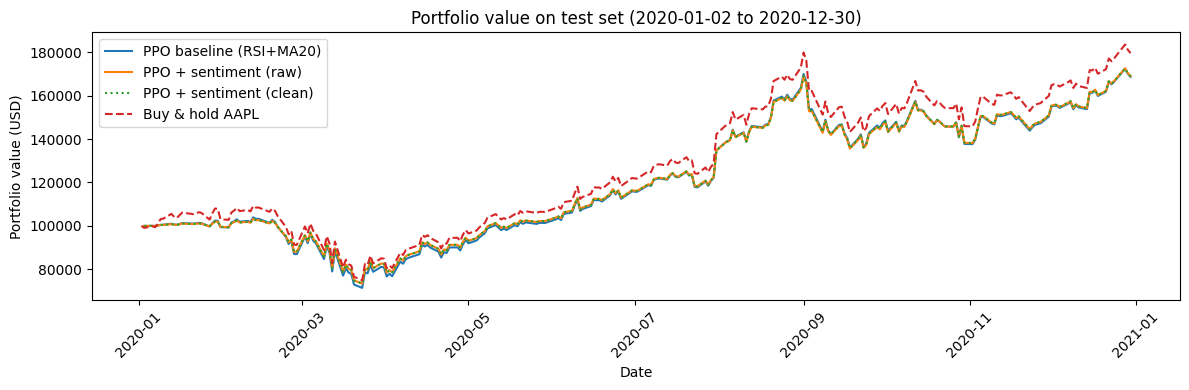

In [ ]:
# --------------------------------
# Visual comparison vs dates + Buy&Hold (3 PPO variants)
# --------------------------------

dates_base = pd.to_datetime(df_account_base["date"])
dates_sent = pd.to_datetime(df_account_sent["date"])
dates_sent_clean = pd.to_datetime(df_account_sent_clean["date"])

plt.figure(figsize=(12, 4))
plt.plot(dates_base, portfolio_values_baseline, label="PPO baseline (RSI+MA20)")
plt.plot(dates_sent, portfolio_values_sentiment, label="PPO + sentiment (raw)")
plt.plot(dates_sent_clean, portfolio_values_sentiment_clean,
         label="PPO + sentiment (clean)", linestyle=":")
# plt.plot(dates_llm, portfolio_values_llm, label="PPO + sentiment (LLM clean)", linestyle="-.")
plt.plot(bh_dates, bh_curve, label="Buy & hold AAPL", linestyle="--")

plt.title("Portfolio value on test set (2020-01-02 to 2020-12-30)")
plt.xlabel("Date")
plt.ylabel("Portfolio value (USD)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


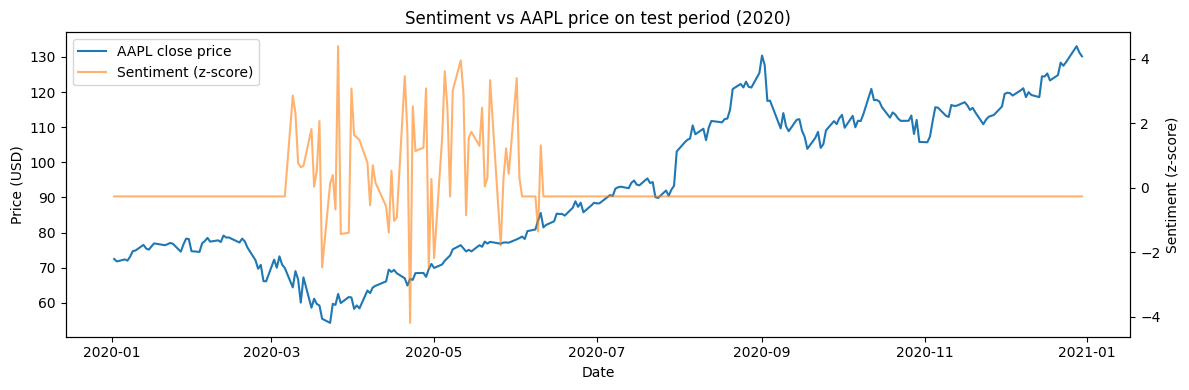

In [ ]:
# ============================================
# 5.3  Sentiment diagnostics: sentiment vs price
# ============================================

diag = test_df.sort_values("date").copy()

fig, ax1 = plt.subplots(figsize=(12, 4))

# Price on primary y-axis
ax1.plot(diag["date"], diag["close"], label="AAPL close price", linewidth=1.5)
ax1.set_xlabel("Date")
ax1.set_ylabel("Price (USD)")

# Sentiment (standardized) on secondary y-axis
ax2 = ax1.twinx()
sent = diag["sentiment"].astype(float)

# Z-score so it shares a comparable scale across time
sent_z = (sent - sent.mean()) / sent.std(ddof=0)
ax2.plot(diag["date"], sent_z, color="tab:orange", alpha=0.6,
         label="Sentiment (z-score)")
ax2.set_ylabel("Sentiment (z-score)")

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.title("Sentiment vs AAPL price on test period (2020)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


On the 2020 out-of-sample test period, all three strategies (PPO baseline, PPO with sentiment, and buy-and-hold AAPL) achieved similar total returns in the 70–80% range. However, the buy-and-hold benchmark still slightly outperforms both PPO variants in terms of raw return. When we evaluate using annualized Sharpe ratios computed from daily log-returns, the PPO baseline achieves a Sharpe that is competitive with, but not clearly superior to, buy-and-hold, while the PPO+sentiment variant is slightly worse on both return and Sharpe. This suggests that, with our current sentiment signal and reward shaping, adding sentiment does not yet deliver a clear risk-adjusted benefit over the simpler technical-indicator baseline. The sentiment-vs-price diagnostic plot further shows that the sentiment series is quite noisy and not obviously aligned with subsequent price trends, which may explain why the RL agent struggles to extract additional value from it.